In [ ]:
# ── Pull the project from GitHub and make `src` importable in Colab ──
import os, sys, subprocess

REPO_URL = "https://github.com/arinzefu/Cross-Modal-Temporal-Prediction-with-RoBERTa-GPT-2-and-CLIP-Guided-Diffusion.git"
REPO_DIR = "/content/Cross-Modal-Temporal-Prediction-with-RoBERTa-GPT-2-and-CLIP-Guided-Diffusion"

if not os.path.exists(REPO_DIR):
    subprocess.run(["git", "clone", REPO_URL, REPO_DIR], check=True)
else:
    subprocess.run(["git", "-C", REPO_DIR, "pull"], check=True)

if REPO_DIR not in sys.path:
    sys.path.insert(0, REPO_DIR)          # so `from src.models... import ...` resolves

req = os.path.join(REPO_DIR, "requirements.txt")
if os.path.exists(req):
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", req], check=True)

print("Repo ready at:", REPO_DIR)
print("src/:", os.listdir(os.path.join(REPO_DIR, "src")))

Repo ready at: /content/Cross-Modal-Temporal-Prediction-with-RoBERTa-GPT-2-and-CLIP-Guided-Diffusion
src/: ['models', 'training', 'utils']


## Visual Autoencoder pretraining

In [1]:
!pip install torchinfo
!pip install clip
!pip install evaluate
!pip install diffusers
!pip install lpips
!pip install torchmetrics

  Preparing metadata (setup.py) ... done
  Created wheel for clip: filename=clip-0.2.0-py3-none-any.whl size=6989 sha256=7f2f69909f944e4fb1bdd4f33e4985b643bd56fd0510837a079025bdd30f4620
  Stored in directory: /root/.cache/pip/wheels/6c/fd/54/9d4e15cf829b871199a7cd3597e869a514d1624a0a43076896
Successfully built clip
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 23.8 MB/s eta 0:00:00


In [2]:
# @title Importing the necessary libraries

import torch
import torch.nn as nn
import torch.nn.functional as F
import clip
from bs4 import BeautifulSoup
import re
import matplotlib.pyplot as plt
import numpy as np
import os
from nltk.translate.bleu_score import sentence_bleu
import json
import pandas as pd
from torchinfo import summary
from transformers import CLIPProcessor, CLIPModel, RobertaModel, RobertaTokenizer
import evaluate
from skimage.metrics import structural_similarity as ssim
from skimage.metrics import peak_signal_noise_ratio as psnr
import tqdm
from datasets.fingerprint import random
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.transforms as transforms
import torchvision.models as models
import torchvision.transforms.functional as FT
import math
from transformers import BertTokenizer
import gc

import textwrap

# **Chapter 1: The data preparation**


---



First we need to activate our google drive so that we can save out data permanently.

## 1.1 Loading and saving data

We need to define a couple of functions to make our life easier. Feel free to tweak those functions:

In [3]:


batch_size = 16
dropout = 0.1
num_layers = 2
device = device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Now we load dataset from HuggingFace:

In [5]:
from datasets import load_dataset

train_dataset = load_dataset("daniel3303/StoryReasoning", split="train")
test_dataset = load_dataset("daniel3303/StoryReasoning", split="test")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/7.94k [00:00<?, ?B/s]

data/train-00000-of-00002.parquet:   0%|          | 0.00/327M [00:00<?, ?B/s]

data/train-00001-of-00002.parquet:   0%|          | 0.00/331M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/115M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/3552 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/626 [00:00<?, ? examples/s]

## 1.2 Three datasets


---



We will create three different dataset objects and the corresponding loaders for performing multiple tasks

In [6]:
# @title CoT improvements toggles (added)
"""
Configuration flags to control which Chain-of-Thought (CoT) mechanisms are used during training:
- `USE_FRAME_AWARE_GROUNDING`: Aligns ROI embeddings with the text embedding of the specific frame (vs global).
- `USE_CONTRASTIVE_ROI`: Enables InfoNCE loss to contrast positive ROI-text pairs against negatives.
- `USE_ENTITY_POOLING`: Enforces consistency of embeddings for the same entity within a batch.
- `USE_COT_TEXT`: Appends CoT reasoning text to the input frame description.
"""

# Turn these on/off to control the 4 optional improvements.
USE_FRAME_AWARE_GROUNDING = True      # Option 2: align ROI to matching frame text embedding (instead of always frame 0)
USE_CONTRASTIVE_ROI = True            # Option 1: InfoNCE-style contrastive grounding using batch negatives
USE_ENTITY_POOLING = True             # Option 3: entity-specific pooling/consistency across batch by entity_id
USE_COT_TEXT = True                   # Option 4: concatenate CoT text snippet to the frame descriptions

# Contrastive temperature (only used if USE_CONTRASTIVE_ROI=True)
CONTRASTIVE_TAU = 0.07

## 1.3 Creating and testing our dataset objects and loaders


---



In [7]:
# @title For the image autoencoder task
"""
Sets up the data pipeline for the auxiliary visual autoencoding task.
Creates the `AutoEncoderDataset` and its `DataLoader`.
"""
import sys
# Add /content to sys.path so helper.py can be found
if '/content' not in sys.path:
    sys.path.insert(0, '/content')

from visual_autoencoder import (
    ReconstructionLoss,
    VisualAutoencoder,
   init_weights,
)
from helper import AutoEncoderTaskDataset
autoencoder_dataset = AutoEncoderTaskDataset(train_dataset)
autoencoder_dataloader = DataLoader(autoencoder_dataset, batch_size=batch_size, shuffle=True)

# **Models**


---



## The Vision models

## 3.1 Initialization and setup

In [8]:
# @title Initializing visual models
"""
1. Instantiates the `VisualAutoencoder`.
2. Applies the custom weight initialization.
"""

visual_autoencoder = VisualAutoencoder(
    latent_dim=128,
    spatial_dim=256,
    unfreeze_layers=2,
).to(device)
visual_autoencoder.decoder.apply(init_weights)

total_params = sum(p.numel() for p in visual_autoencoder.parameters() if p.requires_grad)
print(f"Total trainable parameters in visual autoencoder: {total_params}")


config.json:   0%|          | 0.00/4.10k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/599M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/599M [00:00<?, ?B/s]

Total trainable parameters in visual autoencoder: 26530467


## 3.2 Training loops

In [ ]:

# 3-channel RGB image, 64x64 resolution
dmy_image = torch.randn(batch_size, 3, 64, 64).to(device)

print("===== CLIP Visual Autoencoder Summary =====")
summary(
    visual_autoencoder,
    input_data=dmy_image,
    col_names=["input_size", "output_size", "num_params", "trainable"],
    depth=3
)


===== CLIP Visual Autoencoder Summary =====


Layer (type:depth-idx)                                                 Input Shape               Output Shape              Param #                   Trainable
VisualAutoencoder                                                      [16, 3, 64, 64]           [16, 3, 224, 224]         --                        Partial
├─CLIPEncoderWrapper: 1-1                                              [16, 3, 64, 64]           [16, 128]                 --                        Partial
│    └─CLIPModel: 2-1                                                  --                        --                        63,821,313                Partial
│    │    └─CLIPVisionModel: 3-1                                       --                        [16, 197, 768]            85,799,424                Partial
│    └─Sequential: 2-2                                                 [16, 768]                 [16, 128]                 --                        True
│    │    └─Linear: 3-2                                    

Step 0/1500 | Loss: 2.8090


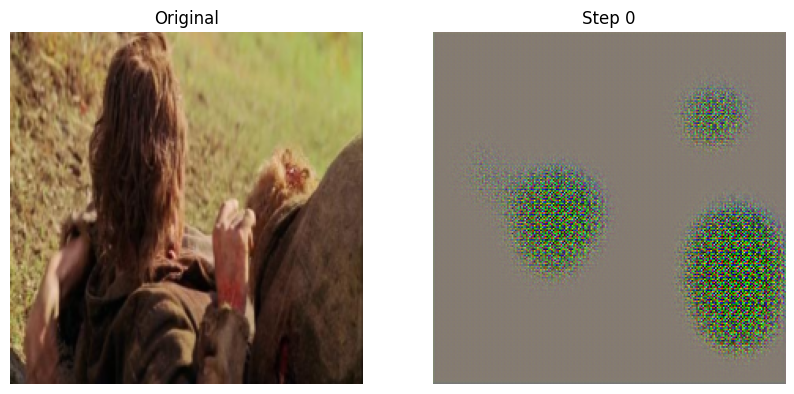

Step 50/1500 | Loss: 2.4163
Step 100/1500 | Loss: 2.2131
Step 150/1500 | Loss: 1.8705
Step 200/1500 | Loss: 1.1821


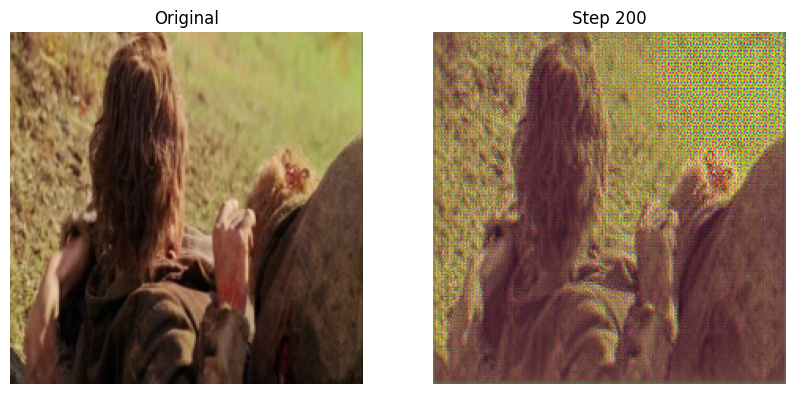

Step 250/1500 | Loss: 0.8148
Step 300/1500 | Loss: 0.6500
Step 350/1500 | Loss: 0.5511
Step 400/1500 | Loss: 0.4922


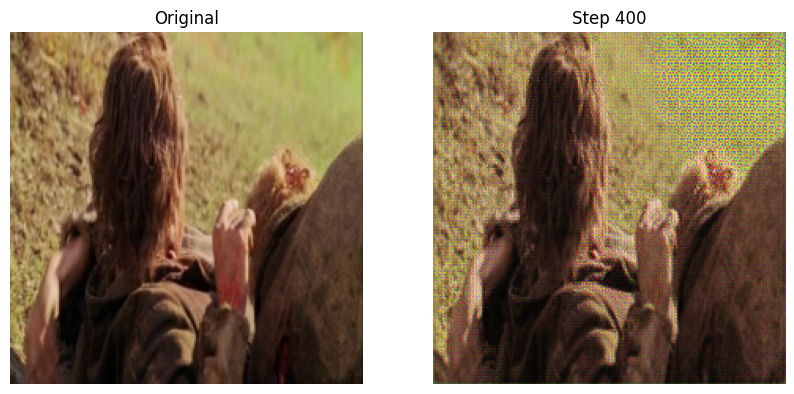

Step 450/1500 | Loss: 0.4445
Step 500/1500 | Loss: 0.4114
Step 550/1500 | Loss: 0.3860
Step 600/1500 | Loss: 0.3594


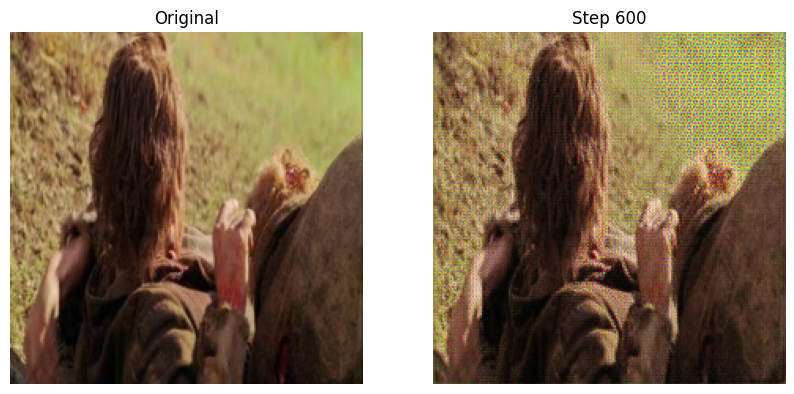

Step 650/1500 | Loss: 0.3419
Step 700/1500 | Loss: 0.3143
Step 750/1500 | Loss: 0.2950
Step 800/1500 | Loss: 0.3049


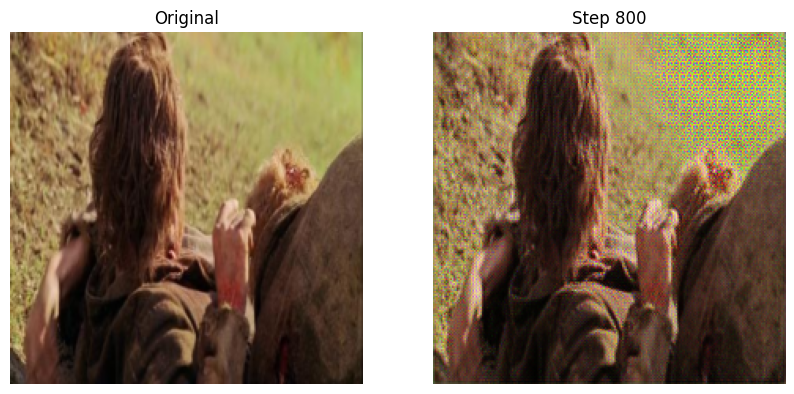

Step 850/1500 | Loss: 0.2726
Step 900/1500 | Loss: 0.2691
Step 950/1500 | Loss: 0.2692
Step 1000/1500 | Loss: 0.2501


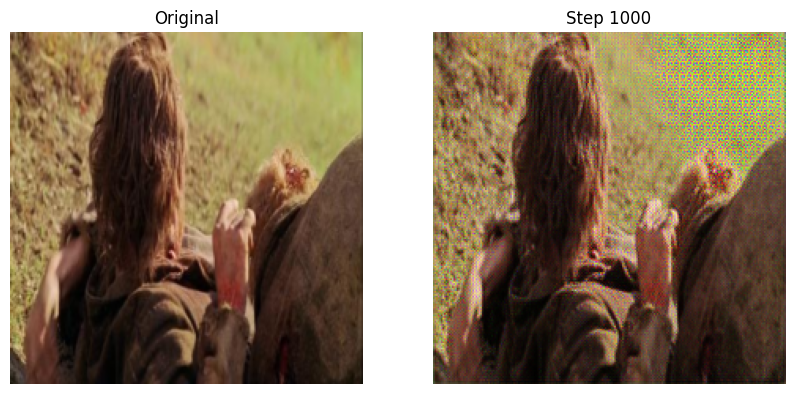

Step 1050/1500 | Loss: 0.2435
Step 1100/1500 | Loss: 0.2353
Step 1150/1500 | Loss: 0.2303
Step 1200/1500 | Loss: 0.2339


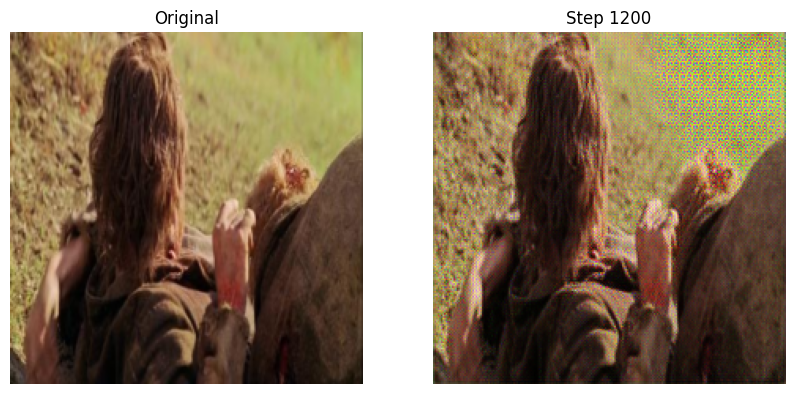

Step 1250/1500 | Loss: 0.2191
Step 1300/1500 | Loss: 0.2211
Step 1350/1500 | Loss: 0.2098
Step 1400/1500 | Loss: 0.1987


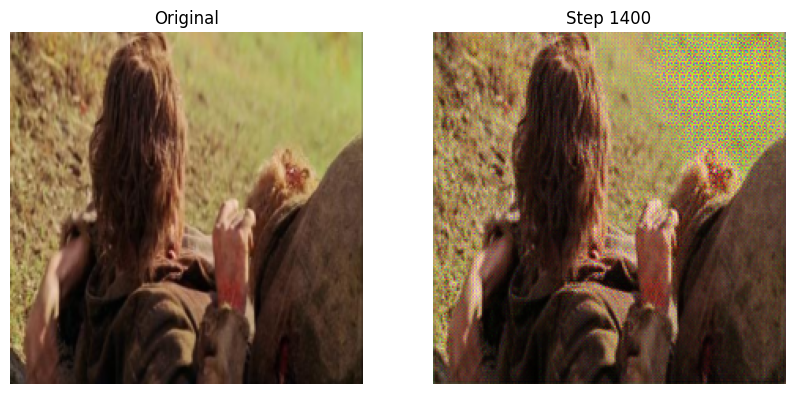

Step 1450/1500 | Loss: 0.1911


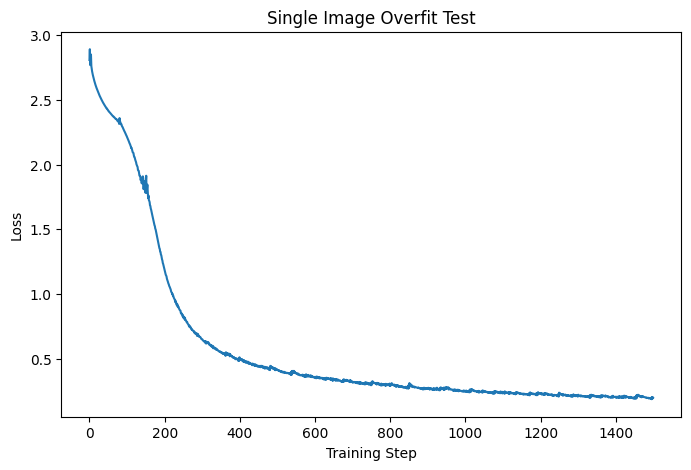

In [ ]:
from visual_test import single_image_overfit_test, _build_default_criterion
from visual_autoencoder import ReconstructionLoss

criterion = ReconstructionLoss(pixel_weight=0.8, perceptual_weight=0.2).to(device)

result = single_image_overfit_test(
    visual_autoencoder,
    dataloader=autoencoder_dataloader,
    device=device,
    criterion=criterion,
    n_steps=1500,
    lr=1e-4,
    log_every=50,
    viz_every=200,
    grad_clip=1.0,
    disable_noise=True,
    show_plots=True,
    verbose=True,
)

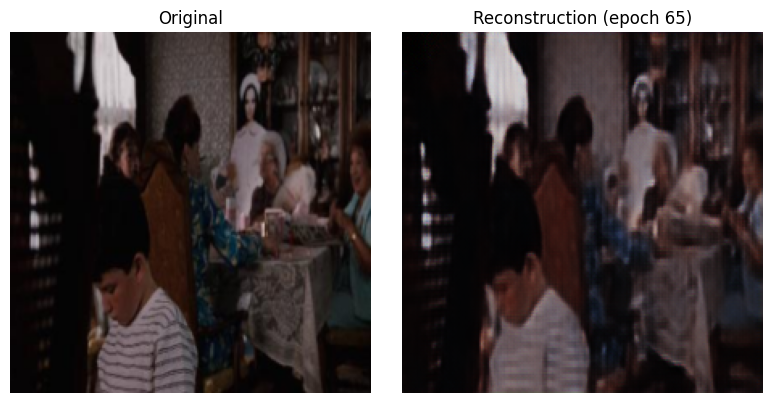

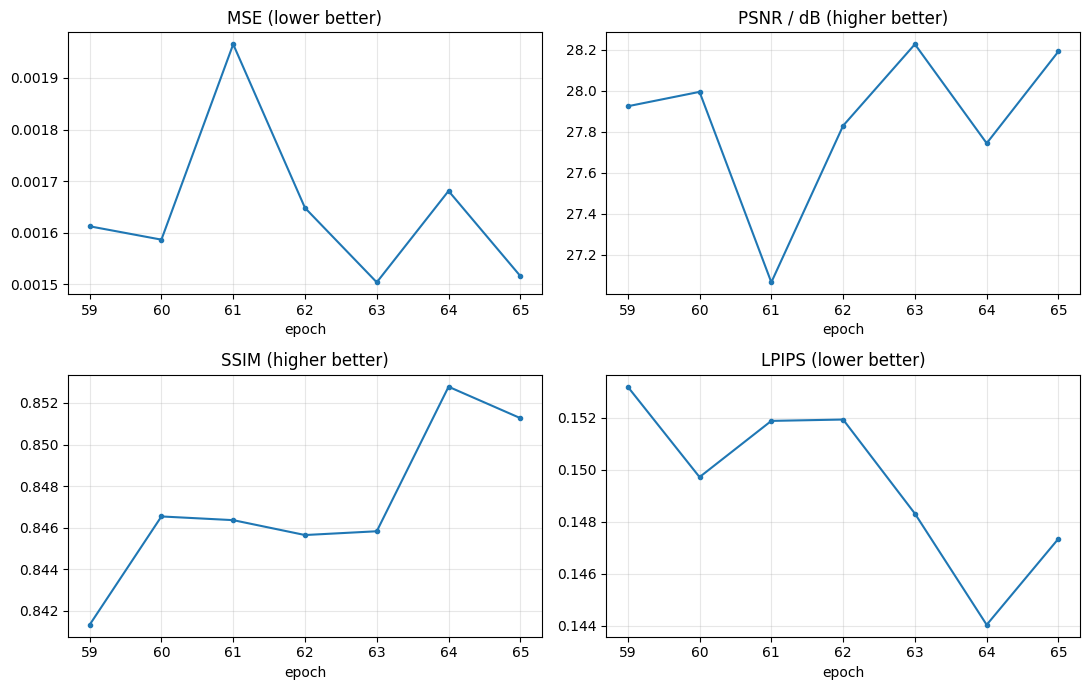

  EarlyStopping: 3/10 epochs without improvement


In [9]:
# =========================================================
# VISUAL AUTOENCODER PRETRAINING
# =========================================================

from tqdm import tqdm
from train_visual import pretrain_visual_autoencoder

history = pretrain_visual_autoencoder(
    model=visual_autoencoder,
    dataloader=autoencoder_dataloader,
    device=device,
    checkpoint_filename="visual_autoencoder.pth",
    n_epochs=65,
    encoder_lr=4e-6,
    decoder_lr=4e-5,
)